In [2]:
from dask.distributed import LocalCluster

# https://forum.access-hive.org.au/t/netcdf-not-a-valid-id-errors/389/12
cluster = LocalCluster(threads_per_worker=1)          # Fully-featured local Dask cluster
client = cluster.get_client()
client

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36713 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:36713/status,
Dashboard: http://127.0.0.1:36713/status,Workers: 56
Total threads: 56,Total memory: 1.11 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34273,Workers: 56
Dashboard: http://127.0.0.1:36713/status,Total threads: 56
Started: Just now,Total memory: 1.11 TiB
Comm: tcp://127.0.0.1:46107,Total threads: 1
Dashboard: http://127.0.0.1:45389/status,Memory: 20.25 GiB
Nanny: tcp://127.0.0.1:43979,


2026-07-17 20:04:17,504 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:43205' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('array-2ef4171d43e33e8118b1b95794761699', 0)} (stimulus_id='handle-worker-cleanup-1784311457.5041385')
2026-07-17 20:04:17,507 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:41165' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('array-5ad4895c03ccd24916947f023a1d6768', 1, 0, 0, 0)} (stimulus_id='handle-worker-cleanup-1784311457.5073717')
2026-07-17 20:04:17,518 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:39259' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'shuffle-taker-5823e457cdc102b93dd5784425c5b7c7'} (stimulus_id='handle-worker-cleanup-1784311457.518475')
Task exception was never retrieved
future: <Task finished name='Task-921510' coro=<Client._gather.<locals>.

# Import 

In [3]:
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import sys
from pathlib import Path
from string import ascii_lowercase, ascii_uppercase

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import HTML, Image, display
from scipy import stats
from aostools import climate#, constants
from scipy.integrate import trapezoid, cumulative_trapezoid
from cmap import Colormap

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


# Functions

In [4]:
def process_daily(ds, deseasonalize=False):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    time_arr = ds.time.values
    ds['time'] = pd.to_datetime(np.floor(time_arr), format = '%Y%m%d')
    #ds["time"] = pd.date_range("2021-01", freq="D", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds#.sel(plev=slice(0.1, 100))

def ComputePsiXr(v, t, lon='lon', lat='lat', pres='level', time='time', ref='mean', p0=1e3):
	"""Computes the residual stream function \Psi* (as a function of time).

		INPUTS:
			v	    - meridional wind, xr.DataArray
			t	    - temperature, xr.DataArray
			lon	    - name of longitude in t
			lat	    - name of latitude in t
			pres	    - name of pressure in t [hPa]
			time	    - name of time field in t
			ref	    - how to treat dTheta/dp:
				       - 'rolling-X' : centered rolling mean over X days
				       - 'mean'	     : full time mean
			p0	    - pressure basis to compute potential temperature [hPa]
		OUTPUTS:
			psi	    - stream function, as a function of time
			psis	    - residual stream function, as a function of time
	"""
	
    # some constants
	from aostools.constants import kappa,a0,g
    
	#
	## compute psi
	v_bar,t_bar = climate.ComputeVertEddyXr(v,t,pres,p0,lon,time,ref) # t_bar = bar(v'Th'/(dTh_bar/dp))

	# Eulerian streamfunction
	pdim = v_bar.get_axis_num(pres)
	psi = v_bar.reduce(cumulative_trapezoid,x=v_bar[pres],axis=pdim,initial=0) # [m.hPa/s]


	## compute psi* = psi - bar(v'Th'/(dTh_bar/dp))
	psis = psi - t_bar
	coslat = np.cos(np.deg2rad(t[lat]))
	psi = 2*np.pi*a0/g*psi *coslat*100 #[kg/s]
	psis= 2*np.pi*a0/g*psis*coslat*100 #[kg/s]

	## give the DataArrays their names
	psi.name = 'psi'
	psis.name= 'psis'

	return psi,psis

In [5]:
xr.set_options(keep_attrs=True)
rootpath = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/")
infile_path =rootpath / "ht"
plt.rcParams.update({"font.size": 22})

# Dataset loading

## WV

In [6]:
what = "H2O_m"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))

In [7]:
time_arr = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
)['time'].values
 

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

In [1]:
ds_w_wv

NameError: name 'ds_w_wv' is not defined

In [8]:
ds_w_wv = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_wv

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 66GB
Dimensions:  (ens: 10, time: 1826, plev: 49, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 66GB dask.array<chunksize=(1, 1826, 49, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 14:43:50 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [9]:
ds_wo_wv = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_wv

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 66GB
Dimensions:  (ens: 10, time: 1826, plev: 49, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 66GB dask.array<chunksize=(1, 1461, 49, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 16:11:55 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [11]:
def average(da, sel_dict = dict(plev = slice(125,225), lat = slice(90,50))):
    return da.sel(**sel_dict).weighted(weights).mean(['lon','plev','ens', 'lat'])

def to_monthly(ds):
    year = ds.time.dt.year
    month = ds.time.dt.month

    # assign new coords
    ds = ds.assign_coords(year=("time", year.data), month=("time", month.data))

    # reshape the array to (..., "month", "year")
    return ds.set_index(time=("year", "month")).unstack("time") 

In [14]:
weights = np.cos(np.deg2rad(ds_w_wv.lat))
wv_lms_w = average(ds_w_wv['H2O_m']).load()
wv_lms_wo = average(ds_wo_wv['H2O_m']).load()

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources

KeyboardInterrupt: 

^^^
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/nanny.py", line 997, in _run
    with contextlib.ExitStack() as stack:
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/contextlib.py", line 469, in _exit_wrapper
    callback(*args, **kwds)
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/contextlib.py", line 601, in __exit__
    raise exc_details[1]
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/threading.py", line 1123, in join
    self._wait_for_tstate_lock(timeout=max(timeout, 0))
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/contextlib.py", line 586, in __exit__
    if cb(

In [ ]:
diff = wv_lms_w-wv_lms_wo
diff.plot(size = 9, lw  =3)

line 157, in _on_sigint
    raise KeyboardInterrupt()
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/utils.py", line 805, in wrapper
    return await func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/worker.py", line 1540, in close
    await self.finished()
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/asyncio/locks.py", line 213, in wait
    await fut
asyncio.exceptions.CancelledError
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/nanny.py", line 1023, in _run
    asyncio_run(run(), loop_factory=get_loop_factory())
  Fil

In [ ]:
da = diff.resample(time=SeasonResampler(["DJF","MAM","JJA",'SON'])).mean()
da#.plot(size = 8)

^^^
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/contextlib.py", line 469, in _exit_wrapper
    callback(*args, **kwds)
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/asyncio/runners.py", line 123, in run
    raise KeyboardInterrupt()
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/threading.py", line 1123, in join
    self._wait_for_tstate_lock(timeout=max(timeout, 0))
KeyboardInterrupt
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/threading.py", line 1139, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
KeyboardInterrupt
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self

In [ ]:
da.to_netcdf('SOCOL_LMS-ts.nc')

In [ ]:
to_monthly(da).plot(row = 'month', size = 8, lw = 3)

2026-07-17 20:04:20,113 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-07-17 20:04:20,188 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/process.py", line 202, in _run
    target(*args, **kwargs)
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/nanny.py", line 1023, in _run
    asyncio_run(run(), loop_factory=get_loop_factory())
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/compatibility.p

In [8]:
dims4ave = ['lon']
diff = ds_w_wv['H2O_m'].mean(dims4ave)-ds_wo_wv['H2O_m'].mean(dims4ave)
sel_dict = dict(lat = slice(None,60), time = slice("2023-09", "2024-04"))
diff_sel = diff.sel(**sel_dict).isel(ens = 0)
weights = np.cos(np.deg2rad(diff.lat))
weights.name = "weights"
diff_sel_pcap = diff_sel.weighted(weights).mean('lat').load()*1e6
diff_sel_pcap.attrs['units'] = 'ppmv'
#diff_sel_pcap.attrs['long_name'] = 'temperature'

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
2026-06-09 15:41:50,764 - distributed.worker.memory - WARNING - Worker is at 82% memory usage. Pausing worker.  Process memory: 16.75 GiB -- Worker memory limit: 20.25 GiB
2026-06-09 15:41:51,005 - distributed.worker.mem

'\ndiff_pcap.sel(\n    time = slice("2023-09", "2024-04"),\n    pressure = slice(100, 0.1),\n).plot.contour(\n    ax = ax, levels = [0], colors = (\'k\'), linewidths = 3, x = \'time\', yincrease = False)'

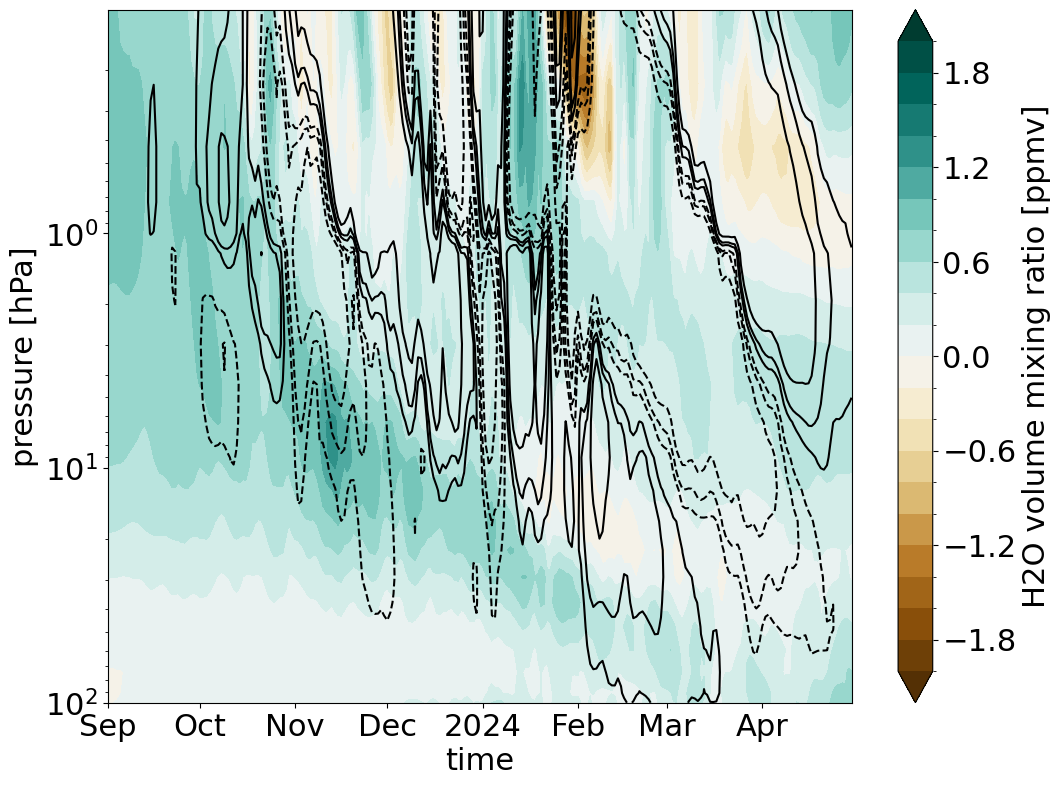

In [49]:
p = (diff_sel_pcap).plot.contourf(x = 'time', yincrease = False, cmap="BrBG", center = 0, extend = 'both', levels = 21, size = 9)
ax = p.axes
ax.set_yscale('log')
diff_pcap.sel(
    time = slice("2023-09", "2024-04"),
    pressure = slice(100, 0.1),
).plot.contour(
    ax = ax, levels = [-1,-0.5,-0.25,0.25, 0.5,1], colors = ('k'), x = 'time', yincrease = False)
"""
diff_pcap.sel(
    time = slice("2023-09", "2024-04"),
    pressure = slice(100, 0.1),
).plot.contour(
    ax = ax, levels = [0], colors = ('k'), linewidths = 3, x = 'time', yincrease = False)"""

'\ndiff_pcap.sel(\n    time = slice("2023-09", "2024-04"),\n    pressure = slice(100, 0.1),\n).plot.contour(\n    ax = ax, levels = [0], colors = (\'k\'), linewidths = 3, x = \'time\', yincrease = False)'

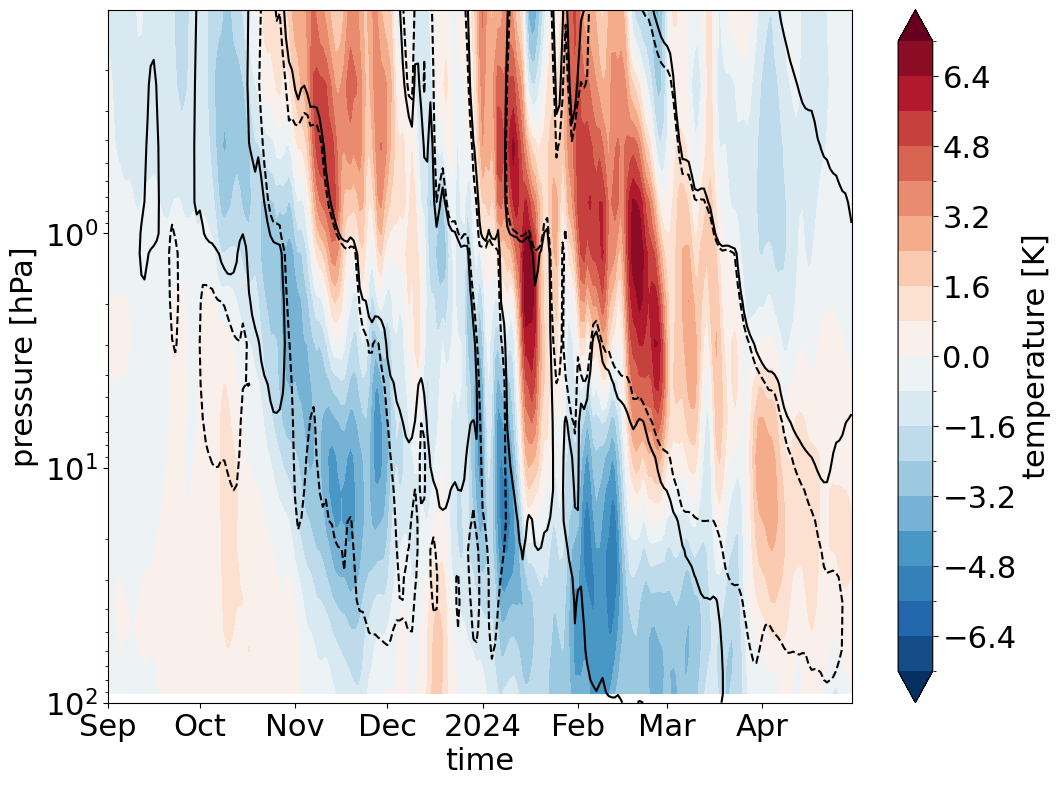

In [63]:
p = diff_t_sel_pcap.plot.contourf(x = 'time', yincrease = False, center = 0, extend = 'both', levels = 21, size = 9)
ax = p.axes
ax.set_yscale('log')
diff_pcap['heating_rate_clearsky'].sel(
    time = slice("2023-09", "2024-04"),
    pressure = slice(100, 0.1),
).plot.contour(
    ax = ax, levels = [-0.2, 0.2], colors = ('k'), x = 'time', yincrease = False)
"""
diff_pcap.sel(
    time = slice("2023-09", "2024-04"),
    pressure = slice(100, 0.1),
).plot.contour(
    ax = ax, levels = [0], colors = ('k'), linewidths = 3, x = 'time', yincrease = False)"""

In [9]:
dims4ave = ['lon']
sel_dict = dict(lat = slice(None,60), time = slice("2023-09", "2024-04"))
arr1 = ds_w_wv['H2O_m'].mean(dims4ave).sel(**sel_dict)
weights = np.cos(np.deg2rad(arr1.lat))
weights.name = "weights"
arr1 = arr1.weighted(weights).mean('lat').load()*1e6
arr2 = ds_wo_wv['H2O_m'].mean(dims4ave).sel(**sel_dict).weighted(weights).mean('lat').load()*1e6
#diff = arr1 - arr2
diff_sel_pcap = arr1.mean('ens') - arr2.mean('ens')
diff_sel_pcap.attrs['units'] = 'ppmv'
#diff_sel_pcap.attrs['long_name'] = 'temperature'

t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=diff_sel_pcap.coords)

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources

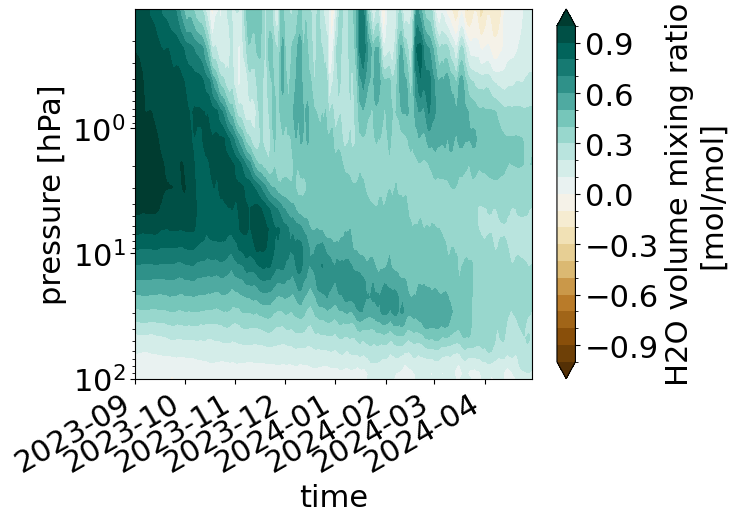

In [24]:
(diff_sel_pcap*1e6).plot.contourf(x = 'time', yincrease = False, robust=True, cmap="BrBG", center = 0, extend = 'both', levels = 21)
plt.yscale('log')

'\ndiff_pcap.sel(\n    time = slice("2023-09", "2024-04"),\n    pressure = slice(100, 0.1),\n).plot.contour(\n    ax = ax, levels = [0], colors = (\'k\'), linewidths = 3, x = \'time\', yincrease = False)\n'

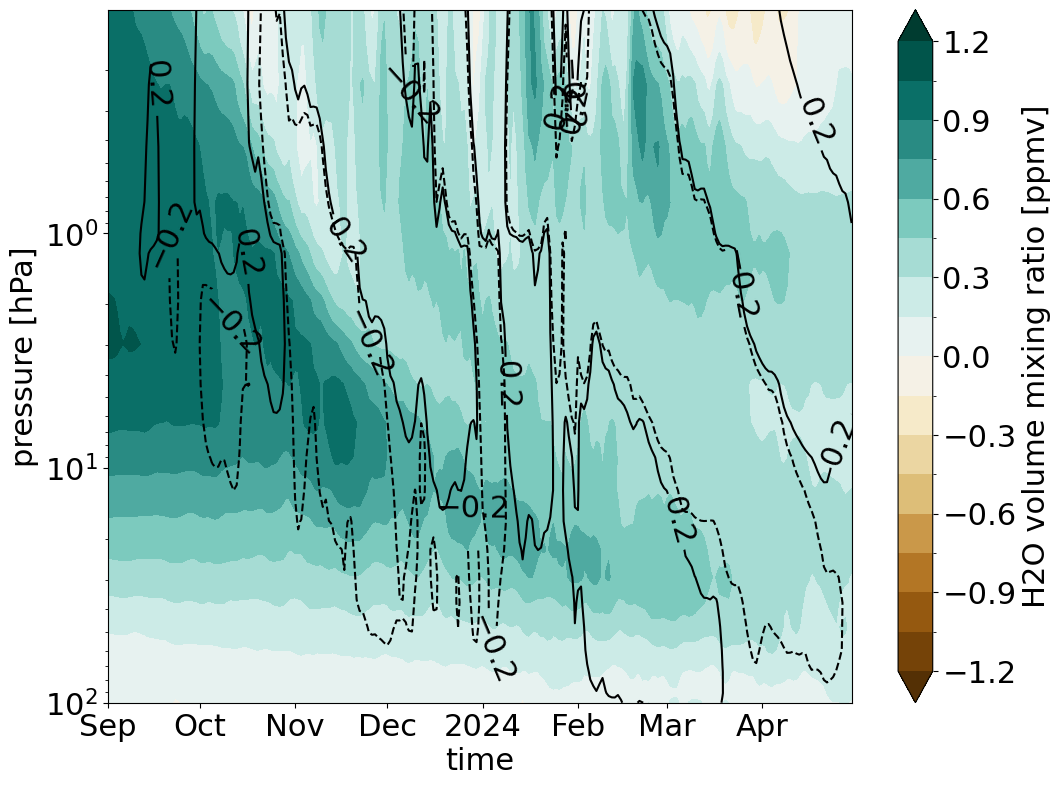

In [87]:
p = (diff_sel_pcap).plot.contourf(x = 'time', yincrease = False, cmap="BrBG", center = 0, extend = 'both', levels = 21, size = 9)
ax = p.axes
ax.set_yscale('log')
CS = diff_pcap['heating_rate_clearsky'].sel(
    time = slice("2023-09", "2024-04"),
    pressure = slice(100, 0.1),
).plot.contour(
    ax = ax, levels = [-0.2, 0.2], colors = ('k'), x = 'time', yincrease = False)
ax.clabel(CS)
"""
diff_pcap.sel(
    time = slice("2023-09", "2024-04"),
    pressure = slice(100, 0.1),
).plot.contour(
    ax = ax, levels = [0], colors = ('k'), linewidths = 3, x = 'time', yincrease = False)
"""

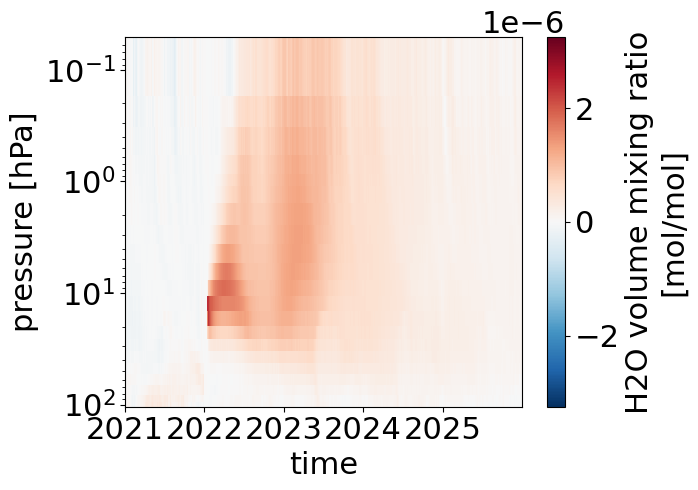

In [142]:
dims4ave = ['ens', 'lon', 'lat']
diff = ds_w_wv['H2O_m'].mean(dims4ave)-ds_wo_wv['H2O_m'].mean(dims4ave)
diff.plot(x = 'time', yincrease = False)
plt.yscale('log')

## EHF

In [10]:
ds_diff_2324 = xr.load_dataset('../ehf_diff_2023-09_2024-04.nc')
#ds_diff_2425 = xr.load_dataset('../ehf_diff_2024-09_2025-04.nc')



## T U V

In [11]:
what = "ta-ua-va_2021-2025.nc"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}"))

In [12]:
ds_w = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    var130   (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:15:52 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [13]:
ds_wo = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_wo

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    var130   (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:16:11 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [14]:
sel_dict = dict(lat = slice(None,None), time = slice("2023-09", "2024-04"))

#temp = ds_w.isel(time=[0], ens = 0)#.mean('lon')
temp = ds_w.sel(**sel_dict)
_, psis_w = ComputePsiXr(temp['v'], temp['var130'], pres='plev')
psis_w = psis_w.expand_dims('experiment')
psis_w['experiment'] = ['with']

#temp = ds_wo.isel(time=[0], ens = 0)#.mean('lon')
temp = ds_wo.sel(**sel_dict)
_, psis_wo = ComputePsiXr(temp['v'], temp['var130'], pres='plev')
psis_wo = psis_wo.expand_dims('experiment')
psis_wo['experiment'] = ['without']

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources

In [18]:
psis_all = xr.merge([psis_w, psis_wo])
psis_all.to_netcdf('psis_SOCOL_202309-202404.nc')

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 83.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 272.09 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size

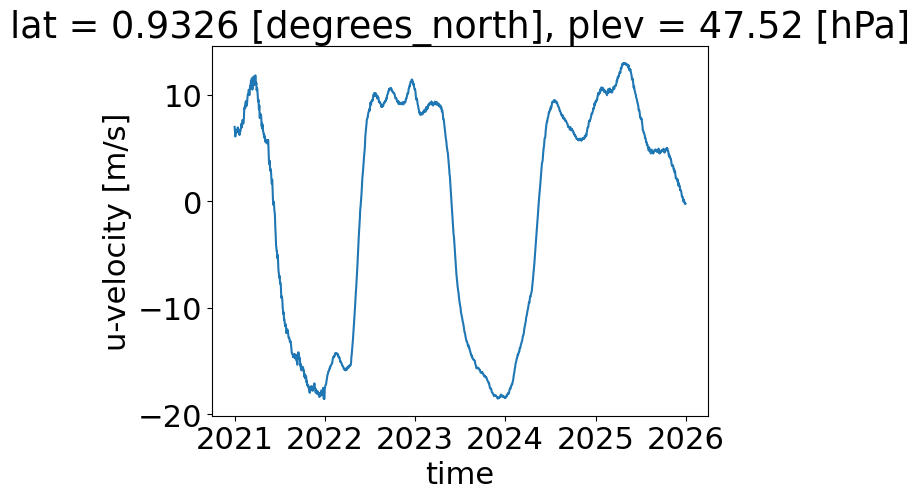

In [32]:
ds_wo['u'].sel(lat = 0, plev = 50, method = 'nearest').mean(['lon','ens']).plot()

In [232]:
import random


In [234]:
random.sample(range(10), 8)

[6, 8, 7, 2, 4, 0, 3, 9]

In [246]:
random.choices(range(10), k=2)

[3, 1]

In [239]:
np.isin(ds_wo.time.dt.month,early_winter)

<xarray.DataArray 'month' (time: 1826)> Size: 15kB
array([ 1,  1,  1, ..., 12, 12, 12])
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31

In [265]:
#early_winter = [11,12,1]
#time_mask = np.isin(ds_wo.time.dt.month,early_winter)
sel_dict = dict(plev = 50, lat = 65, method = 'nearest')
time_slice = slice('2022-11','2023-01')
time_slice = slice('2023-02','2023-04')
time_slice = '2023-03'
ds_wo_u_sel = ds_wo['u'].sel(**sel_dict).mean('lon').sel(time = time_slice).load()
ds_w_u_sel = ds_w['u'].sel(**sel_dict).mean('lon').sel(time = time_slice).load()


In [269]:
ds_w_u_sel

<xarray.DataArray 'u' (ens: 10, time: 31)> Size: 1kB
array([[ 2.16302643e+01,  1.82333431e+01,  1.49740982e+01,
         1.31312418e+01,  1.15917311e+01,  1.25899124e+01,
         1.35891981e+01,  1.30281954e+01,  9.80154705e+00,
         7.08782911e+00,  9.96969318e+00,  1.46721077e+01,
         1.98441334e+01,  2.18946476e+01,  2.29633808e+01,
         2.33036747e+01,  2.13434906e+01,  1.94699478e+01,
         1.79733906e+01,  1.86868839e+01,  1.86277237e+01,
         1.73029995e+01,  1.54424677e+01,  1.30836000e+01,
         1.25338945e+01,  1.11192312e+01,  9.71295166e+00,
         7.81389570e+00,  3.56870294e+00, -3.79351497e-01,
        -2.51523900e+00],
       [-2.30409741e+00, -2.75795460e-01,  2.29110718e-02,
         3.92843813e-01,  1.83172369e+00,  3.43279076e+00,
         5.19280624e+00,  6.74142694e+00,  9.71178722e+00,
         8.68223667e+00,  5.85642815e+00,  1.67930794e+00,
         1.15016747e+00,  1.03504527e+00,  7.26153672e-01,
         2.57953405e+00,  3.99719882e+00,  3.41389632e+00,
         1.07196057e+00, -1.18607533e+00, -6.06667817e-01,
         1.40074480e+00,  2.68086910e+00,  2.75321317e+00,
         2.72431827e+00,  1.83807659e+00,  2.80163288e+00,
...
         5.37222624e+00,  3.43030739e+00,  2.73294258e+00,
         2.89714170e+00,  6.10134268e+00,  1.03356380e+01,
         1.30950155e+01,  1.41198568e+01,  1.53302689e+01,
         1.42639961e+01,  1.09602118e+01,  8.69801998e+00,
         8.00945473e+00,  8.27528000e+00,  8.11996937e+00,
         6.47894812e+00,  5.77050161e+00,  3.39424491e+00,
         7.24734008e-01, -9.82464373e-01, -2.67118573e+00,
        -4.57015133e+00, -4.88248920e+00, -6.44121981e+00,
        -9.12241268e+00],
       [ 1.86043186e+01,  1.62287254e+01,  1.47811728e+01,
         1.64950981e+01,  1.58562937e+01,  1.49472799e+01,
         1.54261513e+01,  1.42956419e+01,  1.49735842e+01,
         1.55439987e+01,  1.47979078e+01,  1.51719294e+01,
         1.60735493e+01,  1.67398739e+01,  1.66185894e+01,
         1.46323557e+01,  1.31199722e+01,  1.23457680e+01,
         1.16411314e+01,  1.21331377e+01,  1.40981369e+01,
         1.64968853e+01,  1.74040279e+01,  1.66365681e+01,
         1.62046833e+01,  1.62606373e+01,  1.71983967e+01,
         1.97645817e+01,  2.29631405e+01,  2.44265156e+01,
         2.49103527e+01]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 248B 2023-03-01 2023-03-02 ... 2023-03-31
    lat      float64 8B 64.35
    plev     float64 8B 47.52
Dimensions without coordinates: ens
Attributes:
    long_name:         u-velocity
    units:             m/s
    code:              131
    table:             128
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48

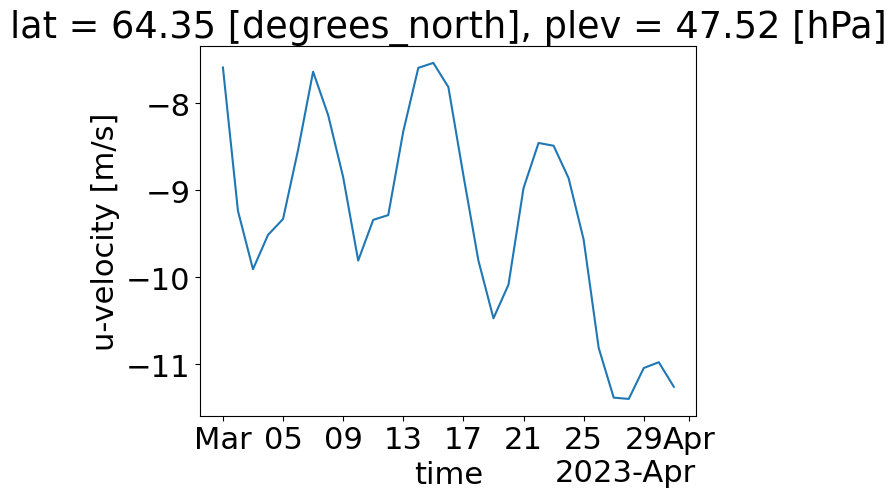

In [270]:
diff_m =  ds_w_u_sel.mean('ens')-ds_wo_u_sel.mean('ens')
diff_m.plot()

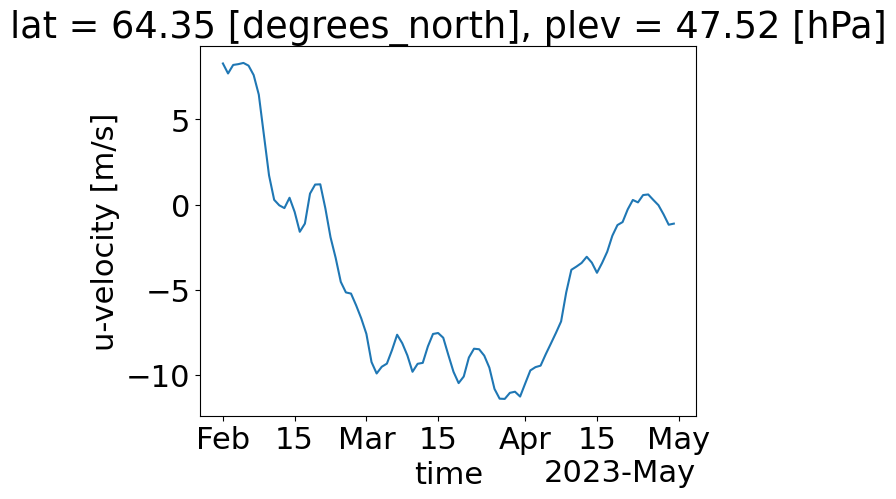

In [261]:
diff_m =  ds_w_u_sel.mean('ens')-ds_wo_u_sel.mean('ens')
diff.plot()

In [267]:
%%time
iterations = 2000
ens_size = 10
x_ls = range(1,ens_size+1)




#fig, ax = plt.subplots(figsize = (12,9))

m_ls = []
s_ls = []
for n_ens in x_ls:    
    diff_ls = []
    for n in range(iterations):
        samples = random.choices(range(ens_size), k=n_ens)
        diff = ds_w_u_sel.isel(ens = samples).mean('ens')-ds_wo_u_sel.isel(ens = samples).mean('ens')
        diff_ls.append(diff)
    rnd_means = xr.concat(diff_ls, dim = 'its')
    #idx = np.random.randint(0, 9, (iterations, n_ens))
    m = rnd_means.mean(['its','time']).values
    #print(m)
    s = rnd_means.std(['its','time']).values
    m_ls.append(m)
    s_ls.append(s)


CPU times: user 38.9 s, sys: 721 ms, total: 39.7 s
Wall time: 38.4 s


In [272]:
 random.choices(range(ens_size), k=3)

[1, 6, 2]

In [271]:
samples

[9, 9, 9, 6, 9, 2, 7, 3, 7, 6]

deltaU65N50hPa_March_2022-2023.pdf


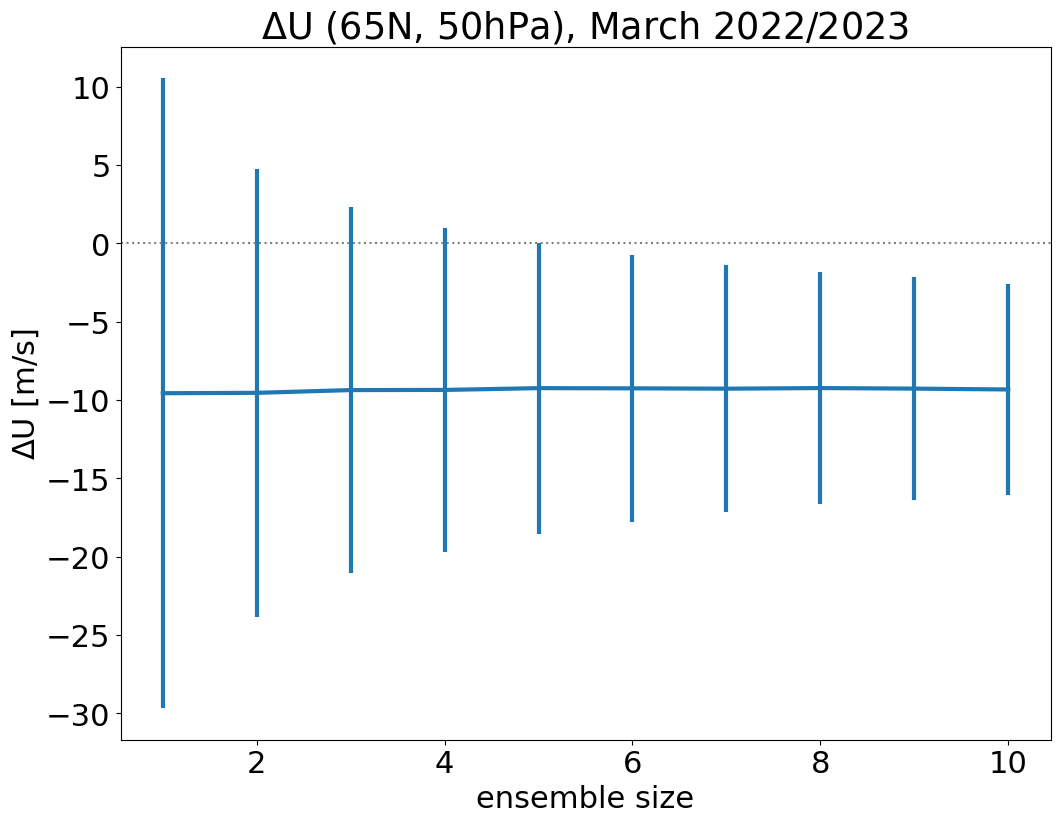

In [268]:
fig, ax = plt.subplots(figsize = (12,9))
ax.errorbar(np.array(x_ls), m_ls, yerr=np.array(s_ls)*2, lw = 3)
ax.axhline(ls = 'dotted', color = 'gray')
ax.set_xlabel('ensemble size')
ax.set_ylabel(r'$\Delta$U [m/s]')
ax.set_title(r'$\Delta$U (65N, 50hPa), March 2022/2023')
outfile = 'deltaU65N50hPa_March_2022-2023.pdf'
print(outfile)
plt.savefig(outfile, bbox_inches = 'tight')

deltaU65N50hPa_FMA_2022-2023.pdf


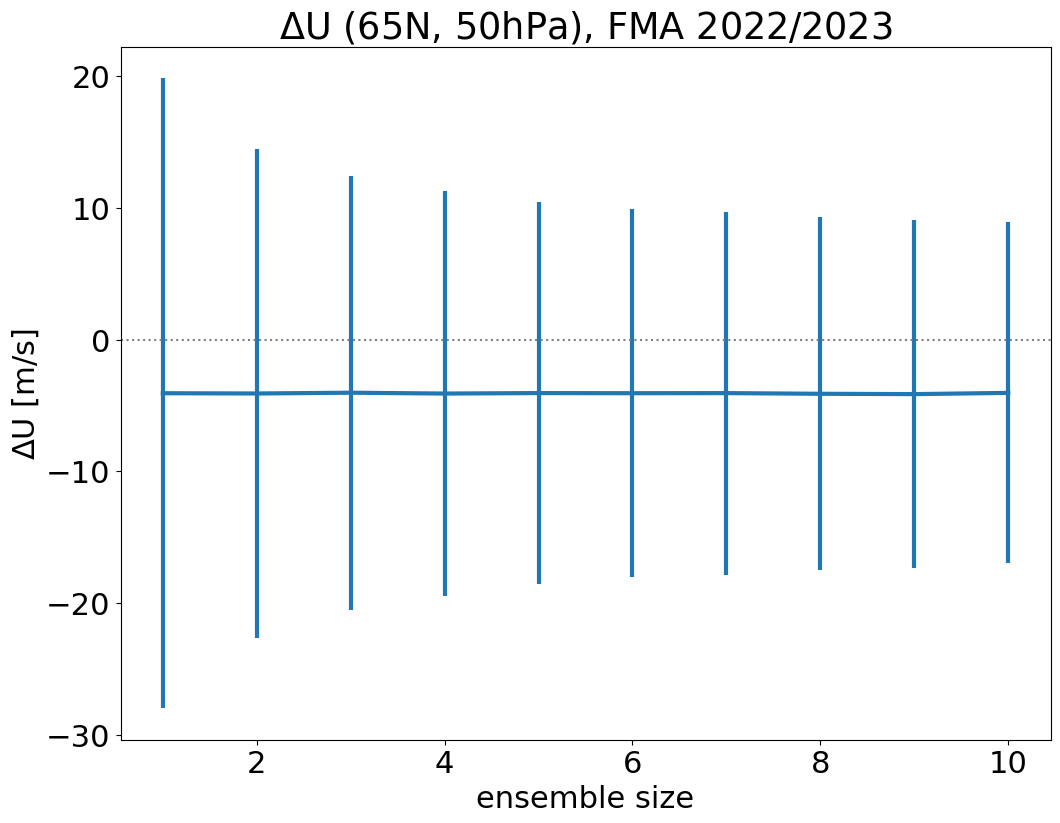

In [264]:
fig, ax = plt.subplots(figsize = (12,9))
ax.errorbar(np.array(x_ls), m_ls, yerr=np.array(s_ls)*2, lw = 3)
ax.axhline(ls = 'dotted', color = 'gray')
ax.set_xlabel('ensemble size')
ax.set_ylabel(r'$\Delta$U [m/s]')
ax.set_title(r'$\Delta$U (65N, 50hPa), FMA 2022/2023')
outfile = 'deltaU65N50hPa_FMA_2022-2023.pdf'
print(outfile)
plt.savefig(outfile, bbox_inches = 'tight')

deltaU65N50hPa_NDF_2022-2023.pdf


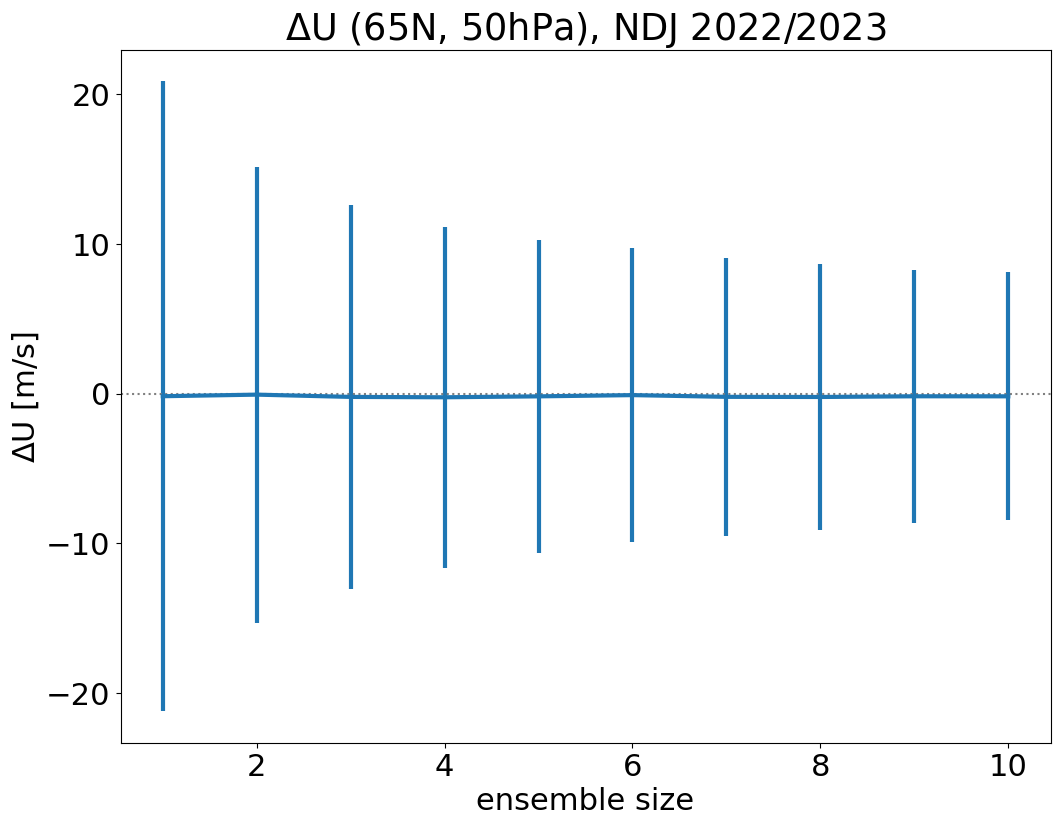

In [259]:
fig, ax = plt.subplots(figsize = (12,9))
ax.errorbar(np.array(x_ls), m_ls, yerr=np.array(s_ls)*2, lw = 3)
ax.axhline(ls = 'dotted', color = 'gray')
ax.set_xlabel('ensemble size')
ax.set_ylabel(r'$\Delta$U [m/s]')
ax.set_title(r'$\Delta$U (65N, 50hPa), NDJ 2022/2023')
outfile = 'deltaU65N50hPa_NDJ_2022-2023.pdf'
print(outfile)
plt.savefig(outfile, bbox_inches = 'tight')

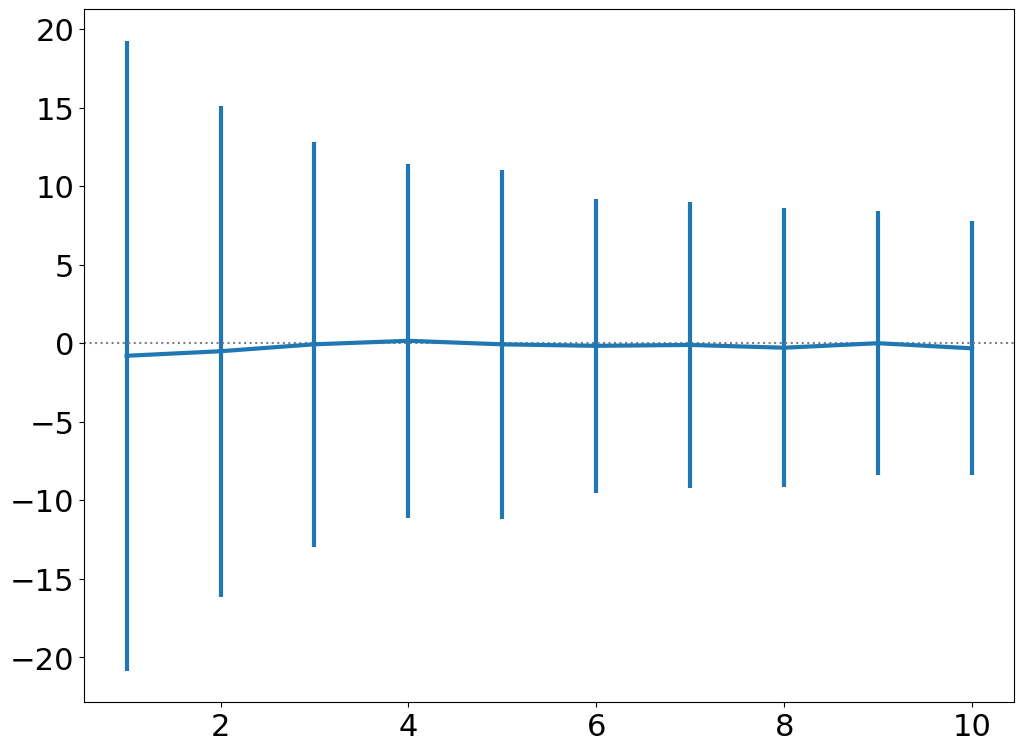

In [251]:
fig, ax = plt.subplots(figsize = (12,9))
ax.errorbar(np.array(x_ls), m_ls, yerr=np.array(s_ls)*2, lw = 3)
ax.axhline(ls = 'dotted', color = 'gray')

In [24]:
dims4ave = ['lon']
sel_dict = dict(time = slice("2023-09", "2024-04"))
arr1_u =  ds_w['u'].mean(dims4ave).sel(**sel_dict).sel(lat = 60, method = 'nearest').load()
arr2_u = ds_wo['u'].mean(dims4ave).sel(**sel_dict).sel(lat = 60, method = 'nearest').load()


diff_u_sel_pcap = arr1_u.mean('ens')-arr2_u.mean('ens')
diff_u_sel_pcap.attrs['units'] = 'm/s'
diff_u_sel_pcap.attrs['long_name'] = 'zonal wind'

t_stat, p_values = stats.ttest_ind(
    arr1_u, arr2_u, equal_var=False
)  # , nan_policy = nan_policy)
diff_u_sel_pcap_pv = xr.DataArray(p_values, coords=diff_u_sel_pcap.coords)


2026-06-09 16:30:00,410 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 15.74 GiB -- Worker memory limit: 20.25 GiB
2026-06-09 16:30:01,986 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 16.20 GiB -- Worker memory limit: 20.25 GiB
2026-06-09 16:30:05,995 - distributed.worker.memory - WARNING - Worker is at 30% memory usage. Resuming worker. Process memory: 6.14 GiB -- Worker memory limit: 20.25 GiB


In [22]:
dims4ave = ['lon']
sel_dict = dict(lat = slice(None,60), time = slice("2023-09", "2024-04"))
arr1 =  ds_w['var130'].mean(dims4ave).sel(**sel_dict)
weights = np.cos(np.deg2rad(arr1.lat))
weights.name = "weights"
arr1 = arr1.weighted(weights).mean('lat').load()
arr2 = ds_wo['var130'].mean(dims4ave).sel(**sel_dict).weighted(weights).mean('lat').load()


diff_t_sel_pcap = arr1.mean('ens')-arr2.mean('ens')
diff_t_sel_pcap.attrs['units'] = 'K'
diff_t_sel_pcap.attrs['long_name'] = 'temperature'

t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_t_sel_pcap_pv = xr.DataArray(p_values, coords=diff_t_sel_pcap.coords)


/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
2026-06-09 16:23:27,087 - distributed.worker.memory - WARNING - Worker is at 83% memory usage. Pausing worker.  Process memory: 16.84 GiB -- Worker memory limit: 20.25 GiB
2026-06-09 16:23:27,605 - distributed.worker.mem

In [50]:
#arr = ds_lw['heating_rate_clearsky']
diff = ds_lw.sel(experiment = 'with') - ds_lw.sel(experiment = 'without')
weights = np.cos(np.deg2rad(arr.lat))
weights.name = "weights"
diff_pcap = diff.weighted(weights).mean('lat')
diff_pcap

<xarray.Dataset> Size: 869kB
Dimensions:                (pressure: 49, time: 1097)
Coordinates:
  * pressure               (pressure) float32 196B 1.009e+03 995.4 ... 0.009946
  * time                   (time) datetime64[ns] 9kB 2022-01-01 ... 2025-01-01
Data variables:
    altitude               (time, pressure) float32 215kB 0.0 0.0 ... 0.0 0.0
    flux_clearsky_down     (time, pressure) float32 215kB 0.6059 -0.273 ... 0.0
    flux_clearsky_up       (time, pressure) float32 215kB 5.187 2.61 ... 0.8239
    heating_rate_clearsky  (time, pressure) float32 215kB 2.903 0.6522 ... 0.0
Attributes:
    history:  Tue Jun 10 17:41:23 2025: ncks -O -x -v spectral_flux_clearsky_...
    NCO:      netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, C...

## NAM

In [20]:
nam_wo = xr.open_dataset('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt2-all_NAM_2021-2025.nc')['nam']
nam_w = xr.open_dataset('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt1-all_NAM_2021-2025.nc')['nam']

In [21]:
diff_nam = nam_w.mean("ens") - nam_wo.mean("ens")
_, p_values = stats.ttest_ind(nam_w, nam_wo, equal_var=False)
diff_nam_pv = xr.DataArray(p_values, coords=diff_nam.coords)
#diff_pv_fdr = xr_multipletest(diff_pv)[1]

## ozone

In [15]:
what = "ozone"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))

In [16]:
ds_w_o3 = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_o3

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:28 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [17]:
ds_wo_o3 = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_o3

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:49 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [18]:
weights = np.cos(np.deg2rad(ds_w_o3.lat))
weights.name = "weights"

dims4ave = ['ens']
sel_dict = dict(lat = slice(None,60), time = slice("2023-09", "2024-04"))
arr1_o3 =  ds_w_o3['O3_m'].sel(**sel_dict).weighted(weights).mean('lat').load()
arr2_o3 =  ds_wo_o3['O3_m'].sel(**sel_dict).weighted(weights).mean('lat').load()

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [19]:
diff_o3_rel = ((arr1_o3.mean("ens")-arr2_o3.mean("ens")) / arr1_o3.mean("ens") * 100)
diff_o3_rel.attrs['units'] = '%'
diff_o3_rel.attrs['long_name'] = 'O3 VMR'


diff_o3 = (arr1_o3.mean("ens")*1e6-arr2_o3.mean("ens")*1e6) 
#diff_o3 = ((arr1-arr2) ).mean("ens")
diff_o3.attrs['units'] = 'ppmv'
diff_o3.attrs['long_name'] = 'O3 VMR'

t_stat, p_values = stats.ttest_ind(
    arr1_o3*1e6, arr2_o3*1e6, equal_var=False
)  # , nan_policy = nan_policy)
diff_o3_pv = xr.DataArray(p_values, coords=diff_o3.coords)

In [20]:
diff_o3_ppmv = (arr1_o3.mean("ens")-arr2_o3.mean("ens")).squeeze()*1e6
anom_o3_ppmv = (arr1_o3-arr2_o3.mean("ens")).squeeze()*1e6

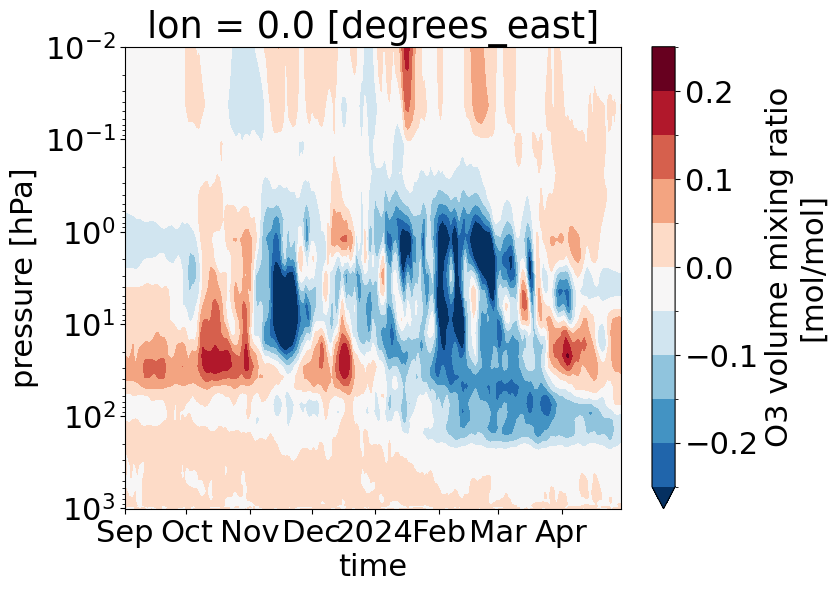

In [30]:
diff_o3_ppmv.squeeze().plot.contourf(x = 'time', yincrease=False, robust = True, levels = 11, size = 6)
plt.yscale('log')

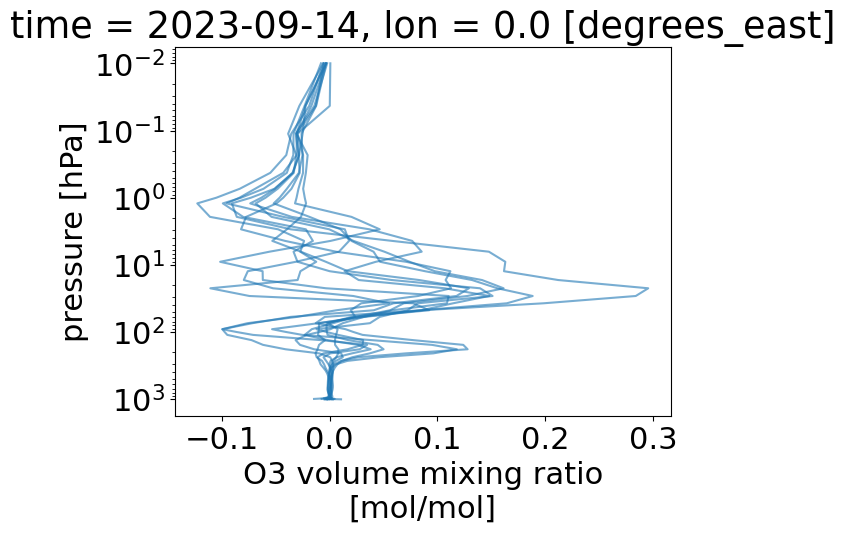

In [20]:
anom_o3_ppmv[:,13,:].plot(y = 'plev', yincrease = False, hue = 'ens', c = 'C0', alpha = 0.6, add_legend = False)
plt.yscale('log')


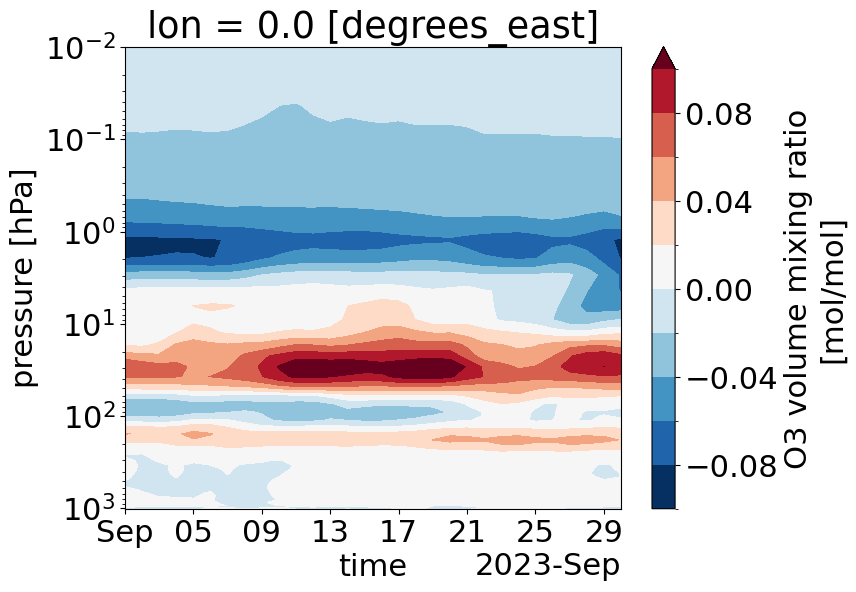

In [31]:
diff_o3_ppmv.squeeze()[:30].plot.contourf(x = 'time', yincrease=False, robust = True, levels = 11, size = 6)
plt.yscale('log')

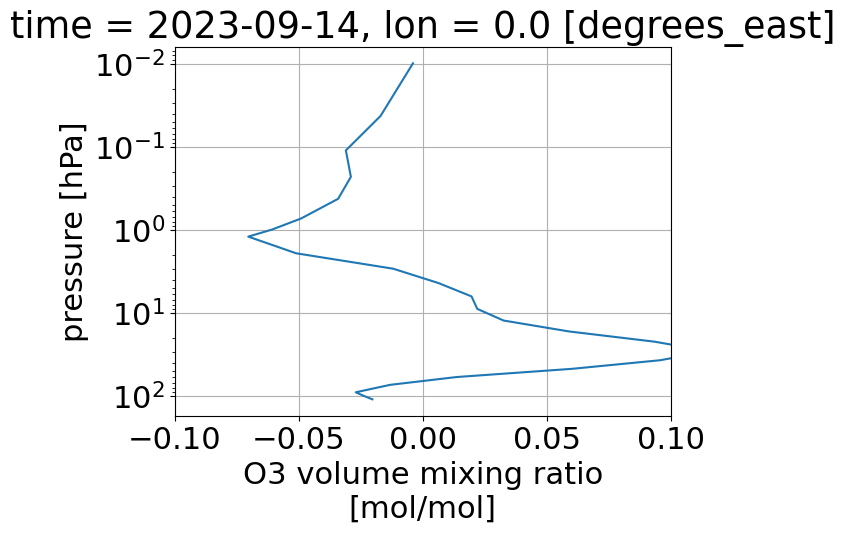

In [54]:
diff_o3_ppmv[13,:-25].plot(yincrease = False, y = 'plev', label = 'ozone')
plt.yscale('log')
plt.xlim(-0.1,0.1)
plt.grid()

In [55]:
diff_o3_ppmv[13,:-25].min()

<xarray.DataArray 'O3_m' ()> Size: 8B
array(-0.07036926)
Coordinates:
    time     datetime64[ns] 8B 2023-09-14
Attributes:
    long_name:         O3 volume mixing ratio
    units:             mol/mol
    code:              11
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48

In [56]:
diff_o3_ppmv[13,:-25].max()

<xarray.DataArray 'O3_m' ()> Size: 8B
array(0.11564761)
Coordinates:
    time     datetime64[ns] 8B 2023-09-14
Attributes:
    long_name:         O3 volume mixing ratio
    units:             mol/mol
    code:              11
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48

In [27]:
anom_o3_ppmv

<xarray.DataArray 'O3_m' (ens: 10, time: 243, plev: 49)> Size: 953kB
array([[[-4.21101960e-03, -1.50935604e-02, -3.76581524e-02, ...,
         -6.77831285e-04, -1.90796327e-03, -6.47199879e-03],
        [-4.76275861e-03, -1.59324993e-02, -3.32481785e-02, ...,
         -6.42250256e-04, -2.15433254e-03, -4.07519143e-03],
        [-4.51746438e-03, -1.68048879e-02, -3.46918810e-02, ...,
         -2.65095824e-03, -3.62511463e-03,  2.29436755e-03],
        ...,
        [-7.85484956e-04, -1.25377264e-03, -1.64075723e-03, ...,
         -3.52014716e-03, -4.30027714e-03, -8.61046981e-03],
        [-1.11820993e-03,  2.67296370e-03,  2.12064461e-03, ...,
         -1.10287672e-03, -4.92908184e-03, -8.12920427e-03],
        [-1.28392934e-03,  4.70846796e-03,  2.93045852e-03, ...,
         -1.20935231e-03, -5.12387933e-03, -1.20214602e-02]],

       [[-3.36780296e-03, -1.19621625e-02, -2.17509392e-02, ...,
         -1.47243708e-03, -6.46082808e-03,             nan],
        [-3.52517526e-03, -1.09342125e-02, -1.92269638e-02, ...,
         -3.22842154e-03, -1.09953169e-02,             nan],
        [-3.72602580e-03, -1.15149117e-02, -2.25375770e-02, ...,
         -3.99609663e-03, -1.47603529e-02,             nan],
...
        [ 5.08064074e-03, -4.39649594e-03, -1.94411272e-03, ...,
         -6.44011910e-05,  1.85327276e-03,  2.06972631e-02],
        [ 3.80176551e-03, -1.92323287e-03, -3.24735581e-03, ...,
          3.44757938e-03,  9.53129213e-03,  1.87233938e-02],
        [ 2.86805562e-03,  7.95276750e-04, -2.39062147e-03, ...,
          2.88290283e-03,  7.90158494e-03,  1.31522441e-02]],

       [[-3.73318901e-03, -1.32210567e-02, -2.83913866e-02, ...,
         -9.08017511e-04, -3.63568457e-03,             nan],
        [-4.01764882e-03, -7.29210320e-03, -2.66399030e-02, ...,
         -1.60154203e-03, -4.93002340e-03,             nan],
        [-3.81930604e-03, -7.53278633e-03, -2.77462276e-02, ...,
         -2.34319469e-03, -9.32291302e-03,             nan],
        ...,
        [ 5.54214690e-03,  8.33429592e-04, -1.12436563e-03, ...,
          1.50574667e-03, -5.05130119e-03,             nan],
        [ 4.43991440e-03,  4.85015080e-03, -3.93282202e-03, ...,
          1.98183141e-03,  5.39392295e-04, -1.28087490e-02],
        [ 2.49628051e-03,  2.43100146e-03, -6.19491566e-03, ...,
          1.41462525e-03, -1.61512323e-04,             nan]]])
Coordinates:
  * time     (time) datetime64[ns] 2kB 2023-09-01 2023-09-02 ... 2024-04-30
    lon      float64 8B 0.0
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Attributes:
    long_name:         O3 volume mixing ratio
    units:             mol/mol
    code:              11
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48

In [30]:
anom_o3_ppmv[:,13,:-25].min()

<xarray.DataArray 'O3_m' ()> Size: 8B
array(-0.12251396)
Coordinates:
    time     datetime64[ns] 8B 2023-09-14
    lon      float64 8B 0.0
Attributes:
    long_name:         O3 volume mixing ratio
    units:             mol/mol
    code:              11
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48

In [29]:
anom_o3_ppmv[:,13,:-25].min('ens')

<xarray.DataArray 'O3_m' (plev: 24)> Size: 192B
array([-0.00792406, -0.02795597, -0.03834596, -0.04008121, -0.0548731 ,
       -0.08316024, -0.10485314, -0.12251396, -0.11076448, -0.08201572,
       -0.05302641, -0.05569639, -0.10137304, -0.07573906, -0.07943556,
       -0.11040571, -0.07422099,  0.02939236,  0.00647505, -0.03604846,
       -0.07601382, -0.09940122, -0.09720143, -0.09472407])
Coordinates:
    time     datetime64[ns] 8B 2023-09-14
    lon      float64 8B 0.0
  * plev     (plev) float64 192B 0.009946 0.04281 0.1112 ... 91.02 100.0 110.7
Attributes:
    long_name:         O3 volume mixing ratio
    units:             mol/mol
    code:              11
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48

Text(0.5, 0, 'VMR [ppmv]')

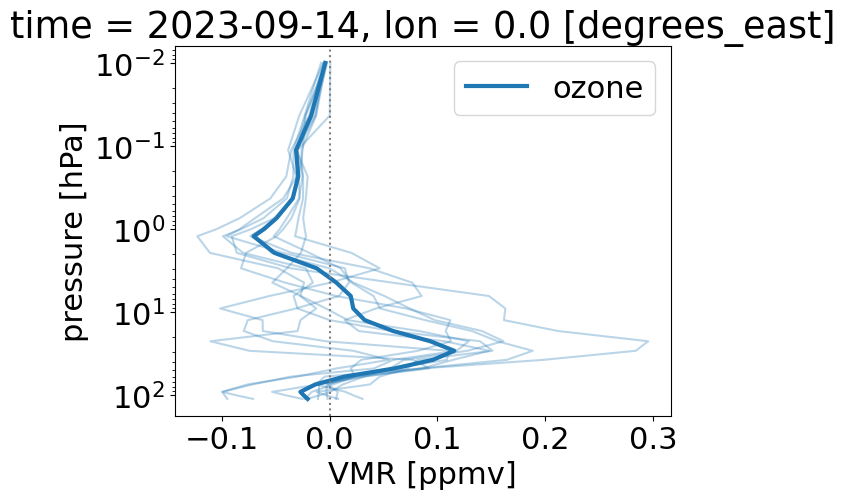

In [28]:
anom_o3_ppmv[:,13,:-25].plot(y = 'plev', yincrease = False, hue = 'ens', c = 'C0', alpha = 0.3, add_legend = False)
diff_o3_ppmv[13,:-25].plot(yincrease = False, y = 'plev', label = 'ozone', c = 'C0', lw = 3)
#diff_sel_pcap[13,:-25].plot(yincrease = False, y = 'plev', label = 'WV', c = 'C1')
plt.axvline(0, ls = 'dotted', c = 'gray')
plt.yscale('log')
plt.legend()
plt.xlabel('VMR [ppmv]')

In [56]:
from aostools.climate import ComputeAnnularMode, TotalColumnOzone, ComputeOzoneHoleArea


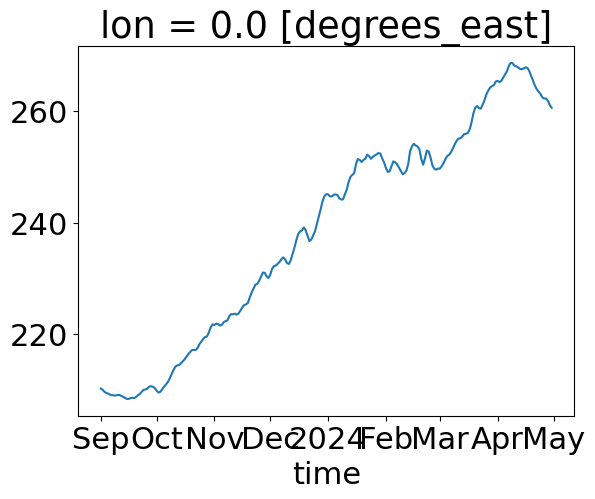

In [59]:
tco_w = TotalColumnOzone(arr1_o3, arr1, pres = 'plev').squeeze()#.load()
tco_wo = TotalColumnOzone(arr2_o3, arr2, pres = 'plev').squeeze()#.load()
tco_w.mean('ens').plot()

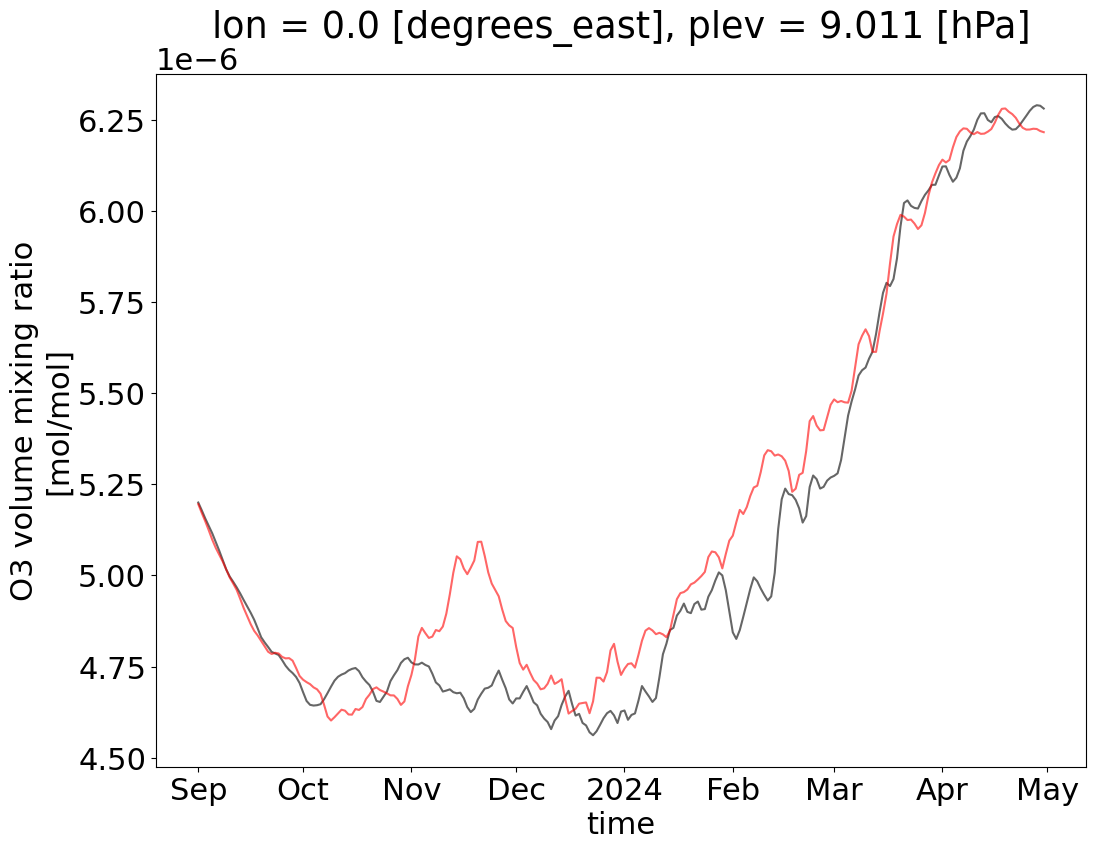

In [138]:
p = arr1.sel(
    plev = 10 , method='nearest'
).mean('ens').squeeze().plot(
    size = 9,
    color = 'k',
    alpha = 0.6
)
ax = p[0].axes
arr2.sel(
    plev = 10 , method='nearest'
).mean('ens').squeeze().plot(
    #size = 9,
    color = 'r',
    alpha = 0.6,
    ax = ax
)

# visualization

### 2023-2024

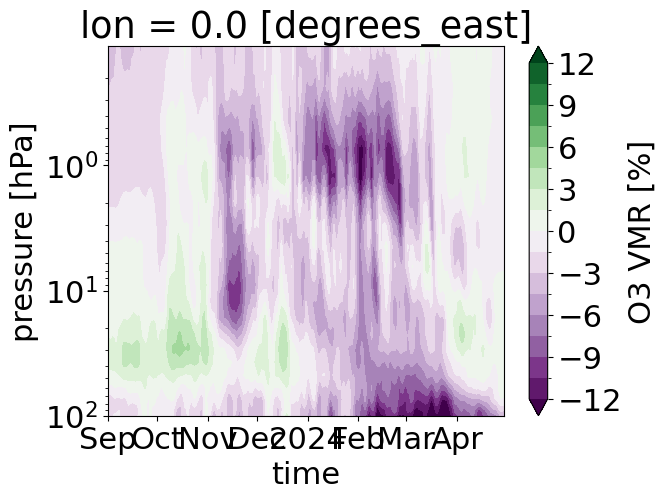

In [156]:
(diff_o3.squeeze()).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = 21,
    cmap = 'PRGn',
     extend='both',
)
plt.yscale('log')

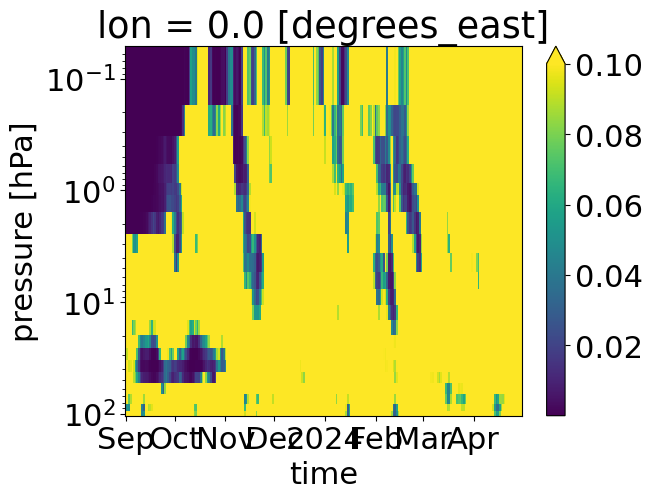

In [183]:
diff_o3_pv.plot(x = 'time', vmax = 0.1, yincrease = False)
plt.yscale('log')

#### with NAM

TE+NAM+WV+O3_time-evolution_2023-2024.pdf


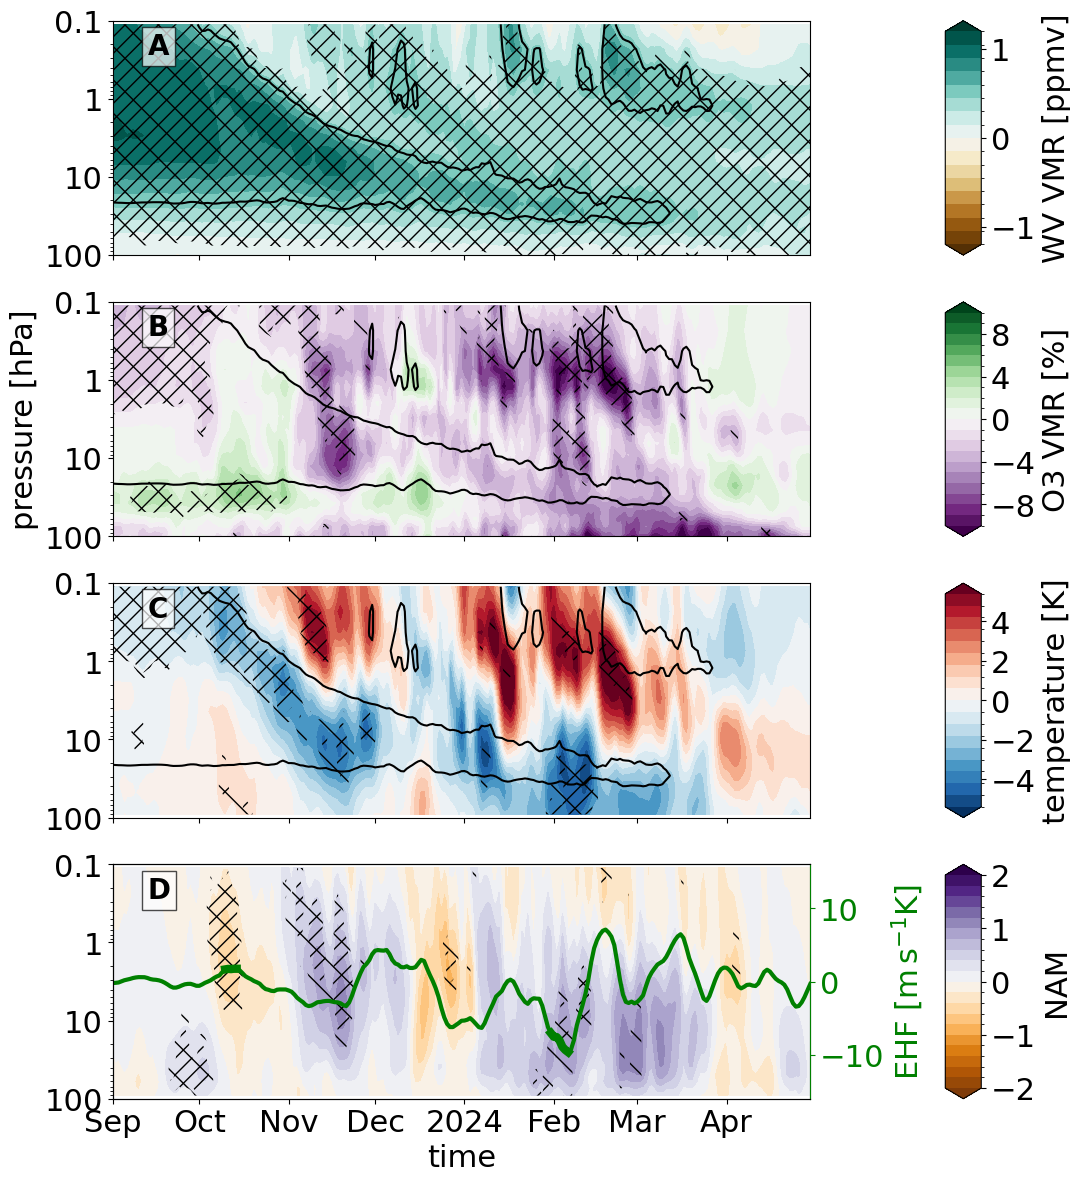

In [51]:
n_rows = 4
f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True)
p_ls = []
ax = axes[0]
p = (diff_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=False, cmap="BrBG", 
    center = 0, extend = 'both', 
    levels = 21, ax = ax,
    add_colorbar = False,
)
p_ls.append(p)
(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)


kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


# ozone
ax = axes[1]
p = (diff_o3.squeeze()).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = 21,
    cmap = 'PRGn',
    ax = ax, extend='both',
    add_colorbar = False,
)
p_ls.append(p)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_o3_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_o3_pv.squeeze().plot.contourf(x="time", **kwargs)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)

ax = axes[2]
p = (diff_t_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = 21,
    ax = ax, extend='both',
    add_colorbar = False,
)
p_ls.append(p)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)



# NAM
ax = axes[-1]
time_sel_dict = dict(time = slice("2023-09", "2024-04"), plev = slice(0.1,100))
p2 = diff_nam.sel(**time_sel_dict).plot.contourf(
    x="time", yincrease=False, 
    levels=21, #robust=False, 
    extend = 'both', 
    cmap="PuOr", ax = ax,
    #cbar_kwargs=dict(label=r"NAM"),
    vmax = 2,
    add_colorbar = False,
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_nam_pv.sel(**time_sel_dict).plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_nam_pv.sel(**time_sel_dict).plot.contourf(x="time", **kwargs)



for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    if i != 1:
        ax.set_ylabel('')
    if i != n_rows-1:
        ax.set_xlabel('')

ax2 = ax.twinx()
temp = ds_diff_2324.sel(plev = 100, method='nearest')#.sel(time = time_slice)
temp['ehf'].plot(ax = ax2, color = 'green', lw = 3)
temp['ehf'].where(temp['pv'] < 0.1).plot(ax = ax2, color = 'green', lw = 6)

ax2.set_ylim(-16,16)
ax2.set_title('')
kwargs = dict(color = 'g')
ax2.set_ylabel(r'EHF [$\mathrm{m\,s^{-1} K}$]',  **kwargs)
ax2.spines['right'].set_color('green')
#ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='y', colors='green')

cx_shift= 0.15
label_ls = ['WV VMR [ppmv]','O3 VMR [%]','temperature [K]']
ticks_ls = [[-1,0,1],[-8,-4,0,4,8],[-6,-4,-2,0,2,4,6],[-2,-1,0,1,2]]
for i, label, p, ticks in zip(range(3),label_ls,p_ls, ticks_ls):
    posn = axes[i].get_position()
    cax = f.add_axes([0.1,-0.1,0.5,0.1])
    
    cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
    f.colorbar(p, cax=cax, orientation='vertical', label=label, extend = 'both', spacing = 'proportional', ticks = ticks)

posn = axes[-1].get_position()
cax = f.add_axes([0.1,-0.1,0.5,0.1])
cx_shift= 0.15
cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
f.colorbar(p2, cax=cax, orientation='vertical', label='NAM', extend = 'both', spacing = 'proportional', ticks = [-6,-3,-2,-1,0,1,2,3,6])


outfile = f"TE+NAM+WV+O3_time-evolution_2023-2024.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

#### with zonal wind

TE+U+WV+O3_time-evolution_2023-2024.pdf


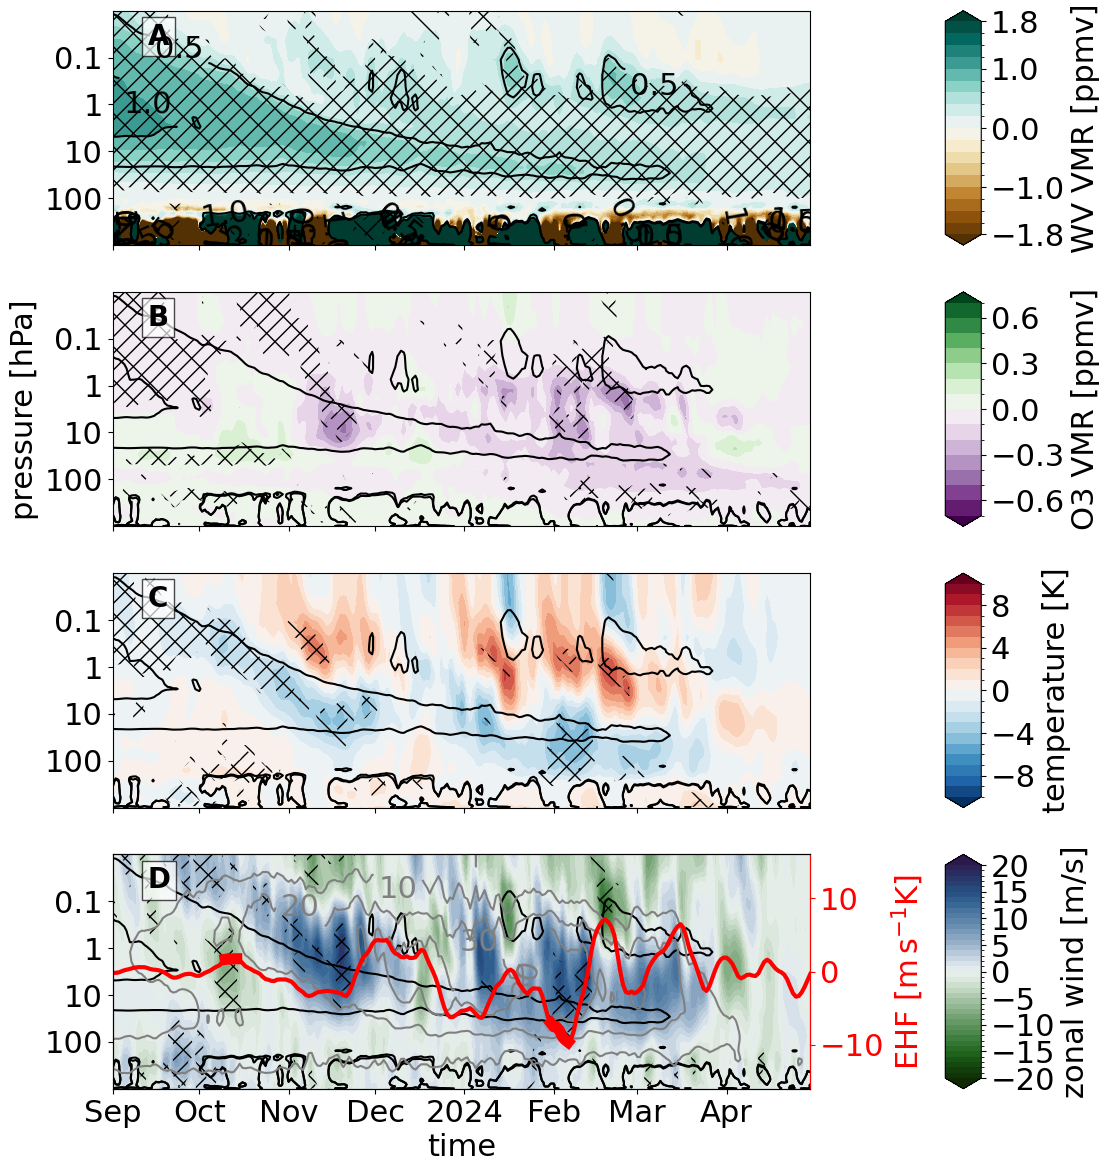

In [25]:
n_rows = 4
t_cmax = 10
t_cmax_step = 1
time_sel_dict = dict(plev = slice(0.1,200)) # time = slice("2023-09", "2024-04"),

f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True)
p_ls = []
ax = axes[0]
p = (diff_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=False, cmap="BrBG", 
    extend = 'both',     
    levels = np.arange(-1.8,2,0.2), ax = ax,
    add_colorbar = False,
)
p_ls.append(p)
CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5,1], colors = ['k'],
)
ax.clabel(CS)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


# ozone
ax = axes[1]
p = (diff_o3.squeeze()).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-.7,.8,0.1),
    cmap = 'PRGn',
    ax = ax, extend='both',
    add_colorbar = False,
)
p_ls.append(p)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

(diff_o3_pv.squeeze()).plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_o3_pv.squeeze().plot.contourf(x="time", **kwargs)

CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5,1], colors = ['k'],
)
#ax.clabel(CS)

# temperature
ax = axes[2]
p = (diff_t_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-t_cmax,t_cmax+t_cmax_step,t_cmax_step), #np.arange(-18,20,2),
    ax = ax, extend='both', cmap = 'RdBu_r',
    add_colorbar = False,
)
p_ls.append(p)

CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5,1], colors = ['k'],
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)



# zonal wind
ax = axes[-1]
cm = Colormap('cork_r')  #'crameri:vik')
cmap = cm.to_matplotlib()

p2 = diff_u_sel_pcap.plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-20,21,1),
    ax = ax, extend='both',
    cmap = cmap,
    add_colorbar = False,
)
p_ls.append(p2)

CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5,1], colors = ['k'],
)
#ax.clabel(CS)

CS = arr1_u.mean('ens').plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [10,20,30], colors = ['gray'],
)
ax.clabel(CS)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)
diff_u_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_u_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
ax.set_title('')

for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    if i != 1:
        ax.set_ylabel('')
    if i != n_rows-1:
        ax.set_xlabel('')

ax2 = ax.twinx()
temp = ds_diff_2324.sel(plev = 100, method='nearest')#.sel(time = time_slice)
temp['ehf'].plot(ax = ax2, color = 'red', lw = 3)
temp['ehf'].where(temp['pv'] < 0.1).plot(ax = ax2, color = 'red', lw = 8)

ax2.set_ylim(-16,16)
ax2.set_title('')
kwargs = dict(color = 'r')
ax2.set_ylabel(r'EHF [$\mathrm{m\,s^{-1} K}$]',  **kwargs)
ax2.spines['right'].set_color('red')
#ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='y', colors='red')

cx_shift= 0.15
label_ls = ['WV VMR [ppmv]','O3 VMR [ppmv]','temperature [K]']
ticks_ls = [[-1.8,-1,0,1,1.8],[-0.9,-0.6,-0.3,0,0.3,0.6,0.9],[-16,-12,-8,-4,0,4,8,12,16],[-2,-1,0,1,2]]
for i, label, p, ticks in zip(range(3),label_ls,p_ls, ticks_ls):
    posn = axes[i].get_position()
    cax = f.add_axes([0.1,-0.1,0.5,0.1])
    
    cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
    f.colorbar(p, cax=cax, orientation='vertical', label=label, extend = 'both', spacing = 'proportional', ticks = ticks)

posn = axes[-1].get_position()
cax = f.add_axes([0.1,-0.1,0.5,0.1])
cx_shift= 0.15
cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
f.colorbar(p2, cax=cax, orientation='vertical', label='zonal wind [m/s]', extend = 'both', spacing = 'proportional', ticks = [-20,-15,-10,-5,0,5,10,15,20])


outfile = f"TE+U+WV+O3_time-evolution_2023-2024.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [26]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")


True

In [27]:
#client.ls("Photos", detail=False)
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

#### with heating rates

TE+NAM+WV+LWHR+O3_time-evolution_2023-2024.pdf


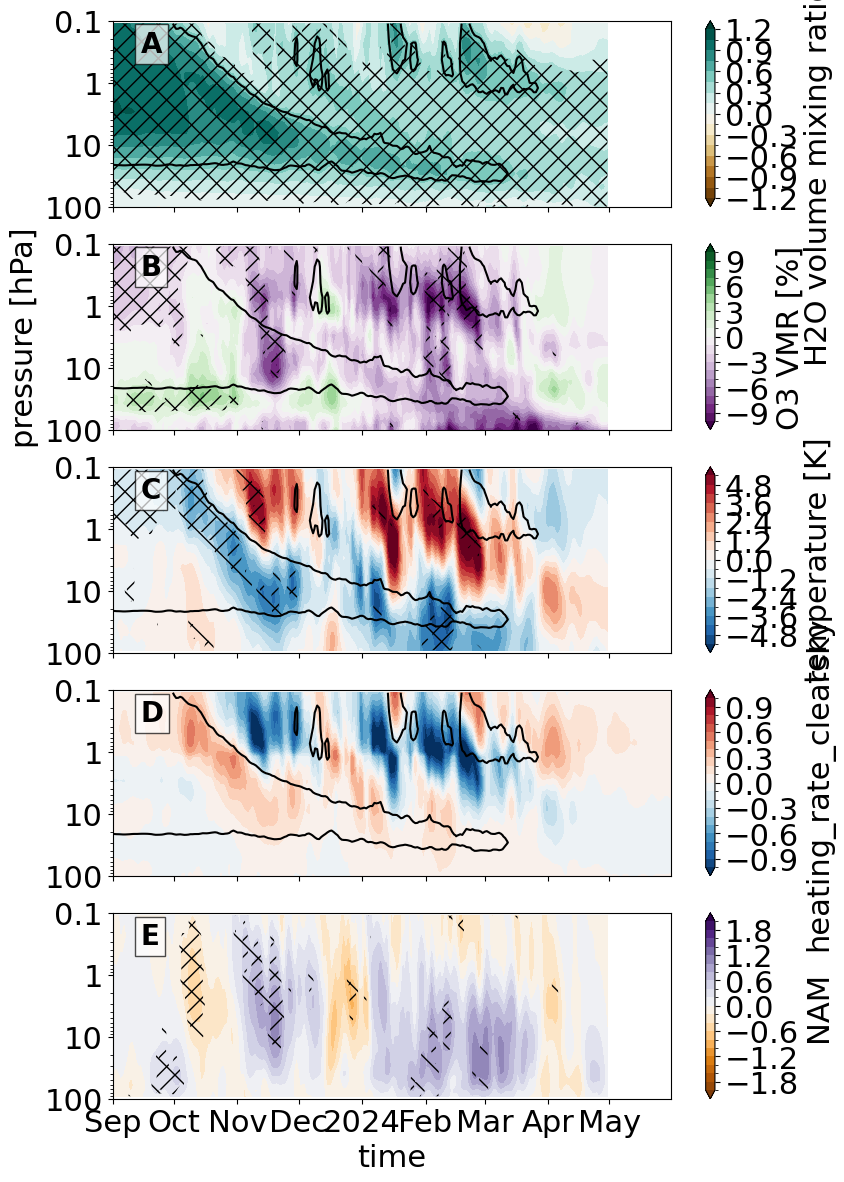

In [284]:
n_rows = 5
f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True, sharey=True)

ax = axes[0]
(diff_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=False, cmap="BrBG", 
    center = 0, extend = 'both', 
    levels = 21, ax = ax,
)
(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)


kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


# ozone
ax = axes[1]
(diff_o3.squeeze()).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = 21,
    cmap = 'PRGn',
    ax = ax, extend='both',
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_o3_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_o3_pv.squeeze().plot.contourf(x="time", **kwargs)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)

ax = axes[2]
(diff_t_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = 21,
    ax = ax, extend='both',
)
(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)

# heating rates
"""
ax = axes[3]
diff_lw.sel(pressure = slice(100,0.1)).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = 21,
    ax = ax, extend='both',
)
(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)
"""
# NAM
ax = axes[-1]
time_sel_dict = dict(time = slice("2023-09", "2024-04"), plev = slice(0.1,100))
diff_nam.sel(**time_sel_dict).plot.contourf(
    x="time", yincrease=False, 
    levels=21, #robust=False, 
    extend = 'both', 
    cmap="PuOr", ax = ax,
    cbar_kwargs=dict(label=r"NAM"),
    vmax = 2,
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_nam_pv.sel(**time_sel_dict).plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_nam_pv.sel(**time_sel_dict).plot.contourf(x="time", **kwargs)

ax2 = ax.twinx()
temp = ds_diff.sel(plev = 100, method='nearest').sel(time = time_slice)
temp['ehf'].plot(ax = ax2, color = 'green', lw = 3)
temp['ehf'].where(temp['pv'] < 0.05).plot(ax = ax2, color = 'green', lw = 6)

for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    if i != 1:
        ax.set_ylabel('')
    if i != n_rows-1:
        ax.set_xlabel('')


outfile = f"TE+NAM+WV+LWHR+O3_time-evolution_2023-2024.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")